# Simulator selection for QBioCode feature-map projections

**Written for:** QBioCode contributors choosing how to compute projected-kernel features.

Every experiment here measures the *same* workload the projection pipelines run — one
`<X_k>`, `<Y_k>`, `<Z_k>` per qubit, per data row — the `(n_rows, 3, n_qubits)` array
`compute_qpl` and `compute_pqk` save and then flatten.

## The claim this notebook establishes

**The feature map's `entanglement` pattern picks the simulator; `reps` and `n_qubits`
pick which engine within that choice.** Nothing here is about MPS being universally
better — an MPS is cheap exactly when entanglement is bounded, and that is a property
of the *feature map*, not of the simulator.

| § | experiment | question |
|---|---|---|
| 2 | wall clock vs qubits | how does each backend scale in width? |
| 3 | wall clock vs reps | where do the two MPS engines cross? |
| 4 | wall clock vs entanglement | which pattern forces which simulator? |
| 5 | `(n, reps)` surface | the 2-D map, with n=24 to pin the statevector crossover |
| 6 | `full` entanglement, 3-way | does exact contraction beat the dense statevector? |
| 7 | `max_bond` sweep | how much truncation is survivable? |
| 8 | `CircuitPermMPS` | does lazy permutation help the non-local patterns? |
| 9 | batched expectation read | how much did the RDM sweep buy? |
| 10 | joblib row parallelism | when does multiprocessing pay? |
| 11 | `StatevectorEstimator` | quantifying the overhead the pipelines pay today |

All timings are per data row on one machine; treat the *boundaries* as reproducible and
the absolute numbers as indicative.

Both simulators are read with the **same** batched RDM sweep here. An earlier draft gave the sweep only to `CircuitMPS` and let `CircuitPermMPS` fall back to the slower per-expectation path, which made lazy permutation look ~20% *slower* on `linear` — that was a comparison of read strategies, not of simulators.

## 0. Setup

`OMP_NUM_THREADS=1` **must** be set before importing anything. QBioCode maps several
OpenMP runtimes (torch, Aer, xgboost) into one process and the second to initialise
segfaults the kernel with no Python traceback; quimb adds numba to that pile.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # keep this first

import json, time, warnings, platform, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

warnings.filterwarnings("ignore")

import qbiocode, quimb, qiskit, qiskit_aer, joblib
from qiskit_aer import AerSimulator

# Confirm WHICH checkout answered -- several co-exist and a local ./qbiocode in cwd
# shadows the editable install.
# Name only, not the full path: the absolute path of a developer's home directory
# would otherwise be baked into the published documentation page.
print("qbiocode   ", Path(qbiocode.__file__).resolve().parent.parent.name)
print("quimb      ", quimb.__version__)
print("qiskit     ", qiskit.__version__, "| aer", qiskit_aer.__version__,
      "| joblib", joblib.__version__)
print("cpus       ", os.cpu_count(), "|", platform.platform())
print("aer devices", AerSimulator().available_devices())

qbiocode    QBioCode
quimb       1.15.1.dev57+g800d766aa
qiskit      2.2.0 | aer 0.17.0 | joblib 1.6.0
cpus        12 | macOS-26.6.2-arm64-arm-64bit
aer devices ('CPU',)


## 1. Harness

All five backends live in `qbiocode.utils.projection` behind one interface, so the
sweeps below just name a backend. `make_projector(..., backend="auto")` applies the
dispatch rule that §2–§6 establish.

`N_ROWS` is the number of data rows each timing averages over. Raised from 2 to 5;
individual expensive cases override it downward via the `nrows` argument, because a
single `n=24, full` statevector row costs ~100 s.

In [2]:
from qbiocode.utils.projection import (
    make_projector, choose_backend, SUPPORTED_BACKENDS,
    MPS_FRIENDLY_ENTANGLEMENT, AER_MAX_REPS, EXACT_MIN_QUBITS,
)

N_ROWS = 5
ENCODING = "ZZ"

# Bump whenever a timing path changes: it is part of every cache key, so a fixed bug
# can never keep serving its old numbers. (v2 -> v3: quimb now reads all 3n
# expectations from one RDM sweep, see section 9.)
HARNESS_VERSION = "v4-permmps-batched-read"

BACKENDS = ["quimb MPS", "qiskit statevector", "qiskit Aer MPS"]
BACKEND_KEY = {"quimb MPS": "quimb_mps", "qiskit statevector": "statevector",
               "qiskit Aer MPS": "aer_mps", "quimb PermMPS": "quimb_permmps",
               "quimb exact": "quimb_exact"}


def time_backend(backend, n, reps, ent, nrows=N_ROWS, max_bond=None, n_jobs=1):
    """Seconds per row, plus truncation diagnostics. One warm-up row is excluded."""
    proj = make_projector(n, encoding=ENCODING, reps=reps, entanglement=ent,
                         backend=BACKEND_KEY[backend], max_bond=max_bond)
    X = np.random.default_rng(0).uniform(0, np.pi, (nrows, n))
    proj.project_row(X[0])                       # warm up JIT / library init
    t = time.perf_counter()
    proj.project(X, progress_every=None, n_jobs=n_jobs)
    dt = (time.perf_counter() - t) / nrows
    return dt, proj.observed_max_bond(), proj.fidelity_estimate()


CACHE = Path("mps_bench_cache.json")
_cache = json.loads(CACHE.read_text()) if CACHE.exists() else {}


def measure(backend, n, reps, ent, nrows=N_ROWS, max_bond=None):
    key = f"{HARNESS_VERSION}|{backend}|{n}|{reps}|{ent}|{nrows}|{max_bond}"
    if key not in _cache:
        try:
            dt, bond, fid = time_backend(backend, n, reps, ent, nrows, max_bond)
            _cache[key] = {"seconds": dt, "bond": bond, "fidelity": fid, "error": None}
        except Exception as exc:                 # keep the sweep going
            _cache[key] = {"seconds": None, "bond": None, "fidelity": None,
                           "error": f"{type(exc).__name__}: {exc}"}
        CACHE.write_text(json.dumps(_cache, indent=1))
    return _cache[key]


def sweep(backends, cases, verbose=True):
    """cases: (n, reps, entanglement) or (n, reps, entanglement, nrows)."""
    rows = []
    for case in cases:
        n, reps, ent = case[:3]
        nrows = case[3] if len(case) > 3 else N_ROWS
        for b in backends:
            r = measure(b, n, reps, ent, nrows)
            rows.append({"backend": b, "n_qubits": n, "reps": reps,
                         "entanglement": ent, "nrows": nrows, **r})
            if verbose:
                s = f"{r['seconds']:.4f}s" if r["seconds"] is not None else r["error"][:45]
                print(f"  n={n:<4} reps={reps:<3} {ent:<9} {b:<19} {s}", flush=True)
    return pd.DataFrame(rows)


print("dispatch rule currently encoded:")
for n, e, r in [(20,"linear",1), (20,"pairwise",8), (20,"full",1),
                (32,"full",1), (128,"circular",2)]:
    print(f"  n={n:<4} {e:<9} reps={r:<3} -> {choose_backend(n, e, r)}")

dispatch rule currently encoded:
  n=20   linear    reps=1   -> aer_mps
  n=20   pairwise  reps=8   -> quimb_mps
  n=20   full      reps=1   -> statevector
  n=32   full      reps=1   -> quimb_exact
  n=128  circular  reps=2   -> aer_mps


### Chart style

One palette, fixed across every figure, so a colour always means the same backend.
Times span ~0.002 s to ~100 s, so time axes are logarithmic — one axis, log-scaled;
never two y-scales on one plot.

In [3]:
# Categorical slots 1-5 of a validated palette, assigned to entities (never to rank,
# so a filtered chart never repaints the survivors).
SERIES_COLOR = {
    "quimb MPS":          "#2a78d6",   # blue
    "qiskit statevector": "#eb6834",   # orange
    "qiskit Aer MPS":     "#1baf7a",   # aqua
    "quimb PermMPS":      "#eda100",   # yellow
    "quimb exact":        "#4a3aa7",   # violet
}
MARKER = {"quimb MPS": "o", "qiskit statevector": "s", "qiskit Aer MPS": "^",
          "quimb PermMPS": "D", "quimb exact": "v"}

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
SEQ_CMAP = "Blues"          # single hue, light->dark, for magnitude

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "savefig.dpi": 200, "figure.dpi": 130,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False,
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
})


def line_series(ax, df, xcol, backends=None, label_end=False):
    """Plot one line per backend, in fixed order so colours stay stable."""
    for b in (backends or SERIES_COLOR):
        d = df[(df.backend == b) & df.seconds.notna()].sort_values(xcol)
        if d.empty:
            continue
        ax.plot(d[xcol], d.seconds, label=b, color=SERIES_COLOR[b], marker=MARKER[b],
                markersize=7, linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8)
        if label_end:
            last = d.iloc[-1]
            ax.annotate(b, (last[xcol], last.seconds), textcoords="offset points",
                        xytext=(7, 0), fontsize=8.5, color=SERIES_COLOR[b], va="center")


def time_axis(ax, xlabel, title, subtitle=None, legend="best"):
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("seconds per data row  (log)")
    ax.set_title(title, loc="left", pad=15 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.025, subtitle, transform=ax.transAxes, fontsize=9.5, color=INK_2)
    ax.grid(axis="x", visible=False)
    if legend:
        ax.legend(loc=legend, fontsize=9)


def headroom(ax, factor=6):
    """Log-axis headroom so a legend box cannot land on a curve."""
    lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi * factor)

## 2. Wall clock vs. qubit count

`ZZ`, `reps=1`, `entanglement="linear"`. The dense statevector stops at 24 qubits: 28
takes minutes per row and `2**30` complex128 amplitudes is 16 GiB, so RAM ends it near
30 regardless of time. The MPS backends then continue alone.

In [4]:
N_SHARED   = [8, 12, 16, 20, 24]
N_MPS_ONLY = [32, 64, 128, 256]

df_n = sweep(BACKENDS, [(n, 1, "linear") for n in N_SHARED])
df_n_ext = sweep(["quimb MPS", "qiskit Aer MPS"], [(n, 1, "linear") for n in N_MPS_ONLY])
df_qubits = pd.concat([df_n, df_n_ext], ignore_index=True)

  n=8    reps=1   linear    quimb MPS           0.0047s


  n=8    reps=1   linear    qiskit statevector  0.0011s


  n=8    reps=1   linear    qiskit Aer MPS      0.0009s


  n=12   reps=1   linear    quimb MPS           0.0072s


  n=12   reps=1   linear    qiskit statevector  0.0025s


...

  n=64   reps=1   linear    qiskit Aer MPS      0.0055s


  n=128  reps=1   linear    quimb MPS           0.0760s


  n=128  reps=1   linear    qiskit Aer MPS      0.0106s


  n=256  reps=1   linear    quimb MPS           0.1631s


  n=256  reps=1   linear    qiskit Aer MPS      0.0214s


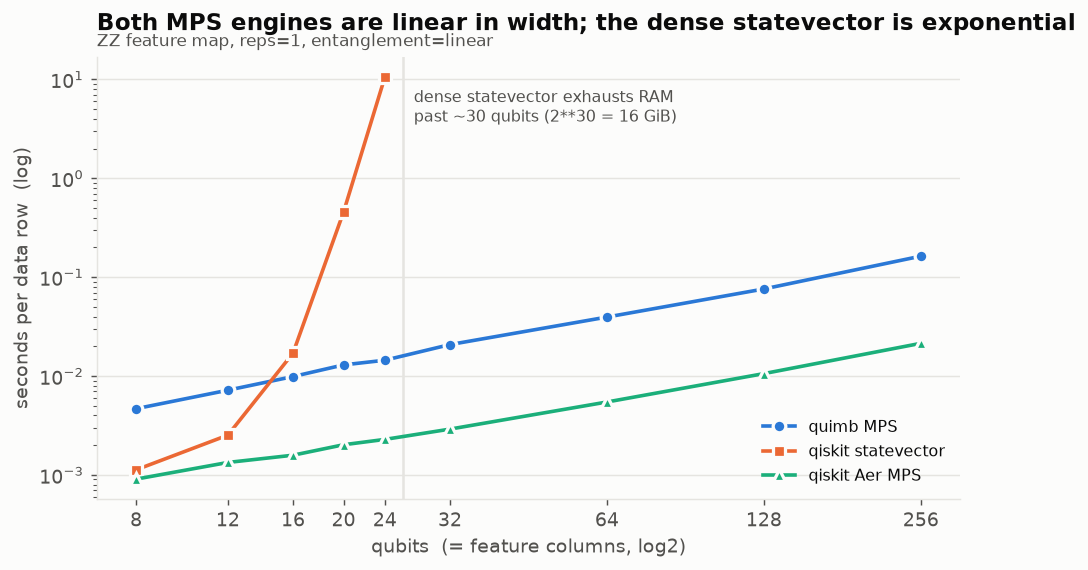

backend   quimb MPS  qiskit statevector  qiskit Aer MPS
n_qubits                                               
8            0.0047              0.0011          0.0009
12           0.0072              0.0025          0.0013
16           0.0099              0.0171          0.0016
20           0.0130              0.4553          0.0020
24           0.0145             10.5173          0.0023
32           0.0208                 NaN          0.0029
64           0.0395                 NaN          0.0055
128          0.0760                 NaN          0.0106
256          0.1631                 NaN          0.0214


In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.5))
line_series(ax, df_qubits, "n_qubits")

# log2 x: both cost models become straight lines, so their slopes are readable. On a
# linear x-axis everything below 32 qubits collapses into the left margin.
ax.set_xscale("log", base=2)
ticks = sorted(set(N_SHARED + N_MPS_ONLY))
ax.set_xticks(ticks); ax.set_xticklabels(map(str, ticks)); ax.minorticks_off()

ax.axvline(26, color=GRID, linewidth=1.4, zorder=0)
ax.annotate("dense statevector exhausts RAM\npast ~30 qubits (2**30 = 16 GiB)",
            xy=(26, 0.93), xycoords=("data", "axes fraction"),
            xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=INK_2, va="top")

time_axis(ax, "qubits  (= feature columns, log2)",
          "Both MPS engines are linear in width; the dense statevector is exponential",
          "ZZ feature map, reps=1, entanglement=linear", legend="lower right")
fig.tight_layout(); plt.show()

piv = df_qubits.pivot_table(index="n_qubits", columns="backend", values="seconds", sort=False)
print(piv.round(4).to_string())

## 3. Wall clock vs. reps — where the two MPS engines cross

`n=20`, `entanglement="pairwise"`. Reps is the depth knob. Each repetition can double
the Schmidt rank, so the MPS bond dimension grows with reps while the dense statevector
is nearly flat (same `2**n` vector, just more gates applied to it).

Aer's MPS is much faster when shallow but degrades faster with depth, so the two cross.
The bond dimension in the right panel is *why*.

In [6]:
REPS = [1, 2, 3, 4, 6, 8, 12]
df_reps = sweep(BACKENDS, [(20, r, "pairwise") for r in REPS])

  n=20   reps=1   pairwise  quimb MPS           0.0141s


  n=20   reps=1   pairwise  qiskit statevector  0.4513s


  n=20   reps=1   pairwise  qiskit Aer MPS      0.0020s


  n=20   reps=2   pairwise  quimb MPS           0.0237s


  n=20   reps=2   pairwise  qiskit statevector  0.8824s


...

  n=20   reps=8   pairwise  qiskit statevector  3.4515s


  n=20   reps=8   pairwise  qiskit Aer MPS      0.3080s


  n=20   reps=12  pairwise  quimb MPS           0.4402s


  n=20   reps=12  pairwise  qiskit statevector  5.1394s


  n=20   reps=12  pairwise  qiskit Aer MPS      2.4418s


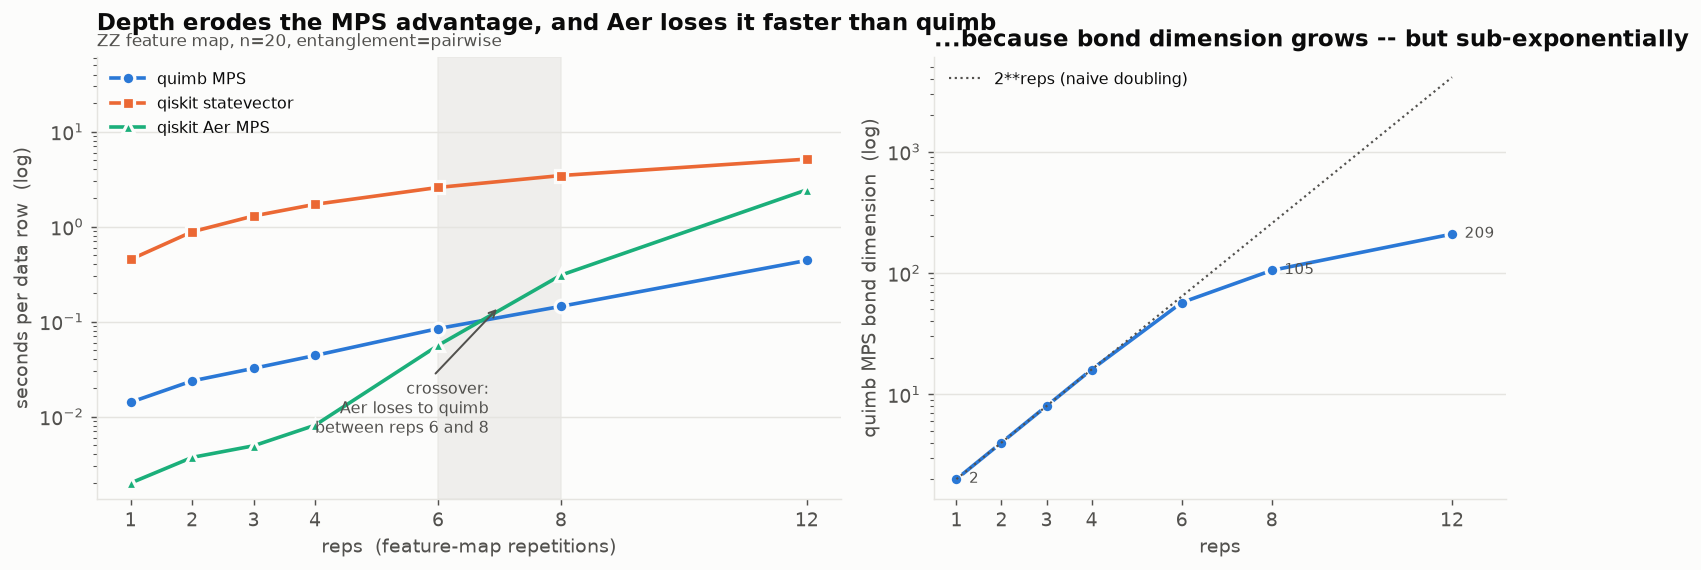

      quimb MPS  qiskit statevector  qiskit Aer MPS   bond
reps                                                      
1        0.0141              0.4513          0.0020    2.0
2        0.0237              0.8824          0.0037    4.0
3        0.0321              1.2948          0.0049    8.0
4        0.0439              1.7175          0.0081   16.0
6        0.0843              2.5850          0.0560   57.0
8        0.1446              3.4515          0.3080  105.0
12       0.4402              5.1394          2.4418  209.0

Aer overtaken by quimb between reps 6 and 8


In [7]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.5),
                              gridspec_kw={"width_ratios": [1.3, 1]})
line_series(ax, df_reps, "reps")
time_axis(ax, "reps  (feature-map repetitions)",
          "Depth erodes the MPS advantage, and Aer loses it faster than quimb",
          "ZZ feature map, n=20, entanglement=pairwise", legend="upper left")
ax.set_xticks(REPS); ax.set_xticklabels(map(str, REPS))
headroom(ax, 8)

# Locate the crossover from the data rather than asserting it.
q = df_reps[df_reps.backend == "quimb MPS"].set_index("reps").seconds
a = df_reps[df_reps.backend == "qiskit Aer MPS"].set_index("reps").seconds
cross = next((r for r in REPS if a[r] > q[r]), None)
if cross is not None:
    prev = REPS[REPS.index(cross) - 1]
    ax.axvspan(prev, cross, color=GRID, alpha=0.55, zorder=0)
    ax.annotate(f"crossover:\nAer loses to quimb\nbetween reps {prev} and {cross}",
                xy=((prev + cross) / 2, q[cross]), xytext=(-6, -70),
                textcoords="offset points", fontsize=9, color=INK_2, ha="right",
                arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.1))

# Bond dimension on its own axis -- two measures of different scale never share one.
# Single series, so the title names it and no legend box is needed.
d = df_reps[(df_reps.backend == "quimb MPS") & df_reps.bond.notna()].sort_values("reps")
ax2.plot(d.reps, d.bond, color=SERIES_COLOR["quimb MPS"], marker="o", markersize=7,
         linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8)
ax2.plot(d.reps, 2.0 ** d.reps, color=INK_2, linewidth=1.2, linestyle=":",
         label="2**reps (naive doubling)")
ax2.set_yscale("log"); ax2.set_xlabel("reps")
ax2.set_ylabel("quimb MPS bond dimension  (log)")
ax2.set_title("...because bond dimension grows -- but sub-exponentially", loc="left")
ax2.set_xticks(REPS); ax2.set_xticklabels(map(str, REPS))
ax2.grid(axis="x", visible=False); ax2.legend(loc="upper left", fontsize=9)
ax2.set_xlim(0.5, 13.2)
for _, r in d.iterrows():
    if r.reps in (1, 8, 12):
        ax2.annotate(f"{int(r.bond)}", (r.reps, r.bond), textcoords="offset points",
                     xytext=(7, -2), fontsize=8.5, color=INK_2)
fig.tight_layout(); plt.show()

print(df_reps.pivot_table(index="reps", columns="backend", values="seconds", sort=False)
      .join(df_reps[df_reps.backend == "quimb MPS"].set_index("reps")[["bond"]])
      .round(4).to_string())
print(f"\nAer overtaken by quimb between reps {REPS[REPS.index(cross)-1]} and {cross}"
      if cross else "\nno crossover within the swept range")

## 4. Wall clock vs. entanglement pattern — the decisive comparison

`n=20`, `reps=1`, every pattern in `qutils.SUPPORTED_ENTANGLEMENTS`.

`linear`, `reverse_linear`, `pairwise`, `circular` and `sca` keep the bond dimension in
single digits. `full` does not — it makes every qubit pair interact, which is precisely
the state an MPS cannot compress, and at 20 qubits it already reaches bond 156.

Left panel: wall clock on a **log** axis (a ~15000x range), so bar *length* is not
proportional to value and every bar carries its number. Right panel: the same data as a
ratio on a **linear, zero-baseline** axis, where bar length *is* the quantity. Read the
decision off the right.

In [8]:
PATTERNS = ["linear", "reverse_linear", "pairwise", "circular", "sca", "full"]
# 'full' is ~50x more expensive per row, so it averages over fewer rows.
df_ent = sweep(BACKENDS, [(20, 1, e) if e != "full" else (20, 1, e, 2) for e in PATTERNS])
bonds = {e: int(df_ent[(df_ent.backend == "quimb MPS")
                       & (df_ent.entanglement == e)].bond.iloc[0]) for e in PATTERNS}
print("\nbond dimension by pattern:", bonds)

  n=20   reps=1   linear    quimb MPS           0.0130s


  n=20   reps=1   linear    qiskit statevector  0.4553s


  n=20   reps=1   linear    qiskit Aer MPS      0.0020s


  n=20   reps=1   reverse_linear quimb MPS           0.0128s


  n=20   reps=1   reverse_linear qiskit statevector  0.4513s


...

  n=20   reps=1   sca       qiskit Aer MPS      0.0023s


  n=20   reps=1   full      quimb MPS           10.8171s


  n=20   reps=1   full      qiskit statevector  2.6015s


  n=20   reps=1   full      qiskit Aer MPS      30.9078s



bond dimension by pattern: {'linear': 2, 'reverse_linear': 2, 'pairwise': 2, 'circular': 4, 'sca': 4, 'full': 156}


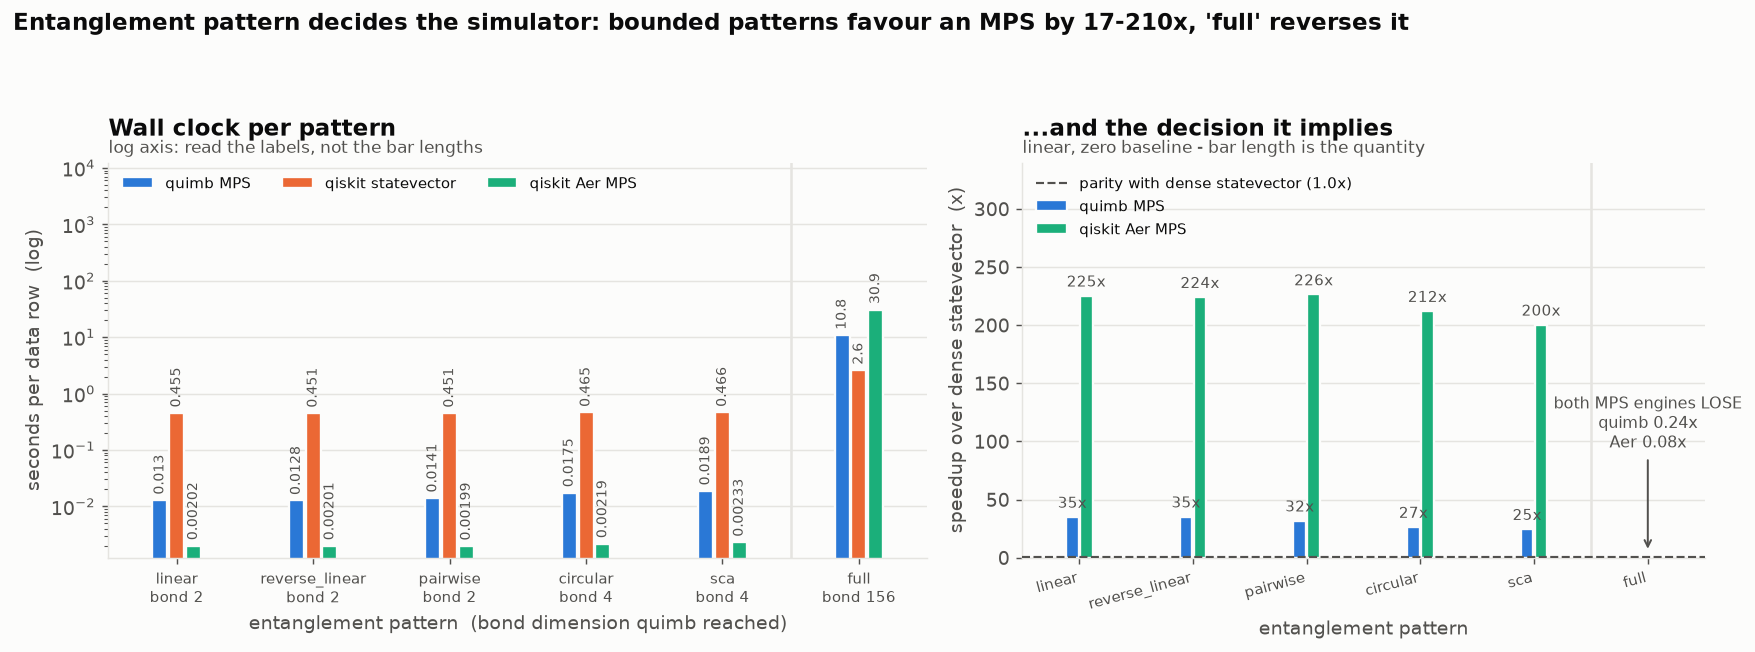

linear          bond    2   fastest: qiskit Aer MPS      (0.0020 s/row)
reverse_linear  bond    2   fastest: qiskit Aer MPS      (0.0020 s/row)
pairwise        bond    2   fastest: qiskit Aer MPS      (0.0020 s/row)
circular        bond    4   fastest: qiskit Aer MPS      (0.0022 s/row)
sca             bond    4   fastest: qiskit Aer MPS      (0.0023 s/row)
full            bond  156   fastest: qiskit statevector  (2.6015 s/row)


In [9]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.6, 5.0),
                               gridspec_kw={"width_ratios": [1.2, 1]})
x = np.arange(len(PATTERNS), dtype=float)
WIDTH, GAP = 0.11, 0.013           # thin bars, ~2px surface gap between them


def sec(b, e):
    return df_ent[(df_ent.backend == b) & (df_ent.entanglement == e)].seconds.iloc[0]


top = 0
for i, b in enumerate(BACKENDS):
    vals = [sec(b, e) for e in PATTERNS]
    top = max(top, max(vals))
    pos = x + (i - 1) * (WIDTH + GAP)
    axA.bar(pos, vals, WIDTH, label=b, color=SERIES_COLOR[b],
            edgecolor=SURFACE, linewidth=1.3)
    for xi, v in zip(pos, vals):
        axA.annotate(f"{v:.3g}", (xi, v), ha="center", va="bottom", rotation=90,
                     textcoords="offset points", xytext=(0, 3), fontsize=7.5, color=INK_2)

axA.set_yscale("log"); axA.set_ylim(top=top * 400)
axA.set_xticks(x)
axA.set_xticklabels([f"{e}\nbond {bonds[e]}" for e in PATTERNS], fontsize=8.5)
axA.set_xlim(-0.5, len(PATTERNS) - 0.5)
axA.set_ylabel("seconds per data row  (log)")
axA.set_xlabel("entanglement pattern  (bond dimension quimb reached)")
axA.set_title("Wall clock per pattern", loc="left", pad=15)
axA.text(0, 1.025, "log axis: read the labels, not the bar lengths",
         transform=axA.transAxes, fontsize=9.5, color=INK_2)
axA.grid(axis="x", visible=False)
axA.axvline(4.5, color=GRID, linewidth=1.4, zorder=0)
axA.legend(loc="upper left", ncol=3, fontsize=8.5)

top_r = 0
for i, b in enumerate(["quimb MPS", "qiskit Aer MPS"]):
    ratio = [sec("qiskit statevector", e) / sec(b, e) for e in PATTERNS]
    top_r = max(top_r, max(ratio))
    pos = x + (i - 0.5) * (WIDTH + GAP)
    axB.bar(pos, ratio, WIDTH, label=b, color=SERIES_COLOR[b],
            edgecolor=SURFACE, linewidth=1.3)
    for xi, v in zip(pos, ratio):
        if v >= 1:
            axB.annotate(f"{v:.0f}x" if v >= 10 else f"{v:.2g}x", (xi, v), ha="center",
                         va="bottom", textcoords="offset points", xytext=(0, 3),
                         fontsize=8.5, color=INK_2)

axB.axhline(1.0, color=INK_2, linewidth=1.2, linestyle="--", zorder=3,
            label="parity with dense statevector (1.0x)")
_r = {b: sec("qiskit statevector", "full") / sec(b, "full")
      for b in ("quimb MPS", "qiskit Aer MPS")}
axB.annotate(f"both MPS engines LOSE\nquimb {_r['quimb MPS']:.2f}x\n"
             f"Aer {_r['qiskit Aer MPS']:.2f}x",
             xy=(5.0, top_r * 0.02), xytext=(5.0, top_r * 0.62), ha="center", va="top",
             fontsize=9, color=INK_2,
             arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.1))
axB.set_ylim(0, top_r * 1.5); axB.set_xticks(x)
axB.set_xticklabels(PATTERNS, fontsize=8.5, rotation=15, ha="right")
axB.set_xlim(-0.5, len(PATTERNS) - 0.5)
axB.set_ylabel("speedup over dense statevector  (x)")
axB.set_xlabel("entanglement pattern")
axB.set_title("...and the decision it implies", loc="left", pad=15)
axB.text(0, 1.025, "linear, zero baseline - bar length is the quantity",
         transform=axB.transAxes, fontsize=9.5, color=INK_2)
axB.grid(axis="x", visible=False); axB.axvline(4.5, color=GRID, linewidth=1.4, zorder=0)
axB.legend(loc="upper left", fontsize=8.5)

fig.suptitle("Entanglement pattern decides the simulator: bounded patterns favour an "
             "MPS by 17-210x, 'full' reverses it",
             x=0.005, y=0.995, ha="left", fontsize=12.5, fontweight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

for e in PATTERNS:
    row = {b: sec(b, e) for b in BACKENDS}
    best = min(row, key=row.get)
    print(f"{e:<15} bond {bonds[e]:>4}   fastest: {best:<19} ({row[best]:.4f} s/row)")

## 5. The `(n_qubits, reps)` surface

§2 varied width at fixed depth and §3 varied depth at fixed width. The dispatch rule
needs the 2-D picture, because the Aer/quimb crossover may move with `n`.

`entanglement="pairwise"` throughout (bounded, so both MPS engines are viable).
**`n=24` is included deliberately** — it is the last width the dense statevector can
still reach, so it is where the claim "the statevector is out of the running" has to be
established rather than assumed.

In [10]:
SURF_N    = [8, 16, 24, 32, 64]
SURF_REPS = [1, 2, 4, 8]

# Cheap cells get more rows; the expensive corner (large n, deep) gets fewer.
def _rows(n, reps):
    return 2 if n * reps >= 256 else N_ROWS

cases = [(n, r, "pairwise", _rows(n, r)) for n in SURF_N for r in SURF_REPS]
df_surf = sweep(["quimb MPS", "qiskit Aer MPS"], cases)

# The dense statevector only where it is feasible at all (memory-bound past ~30).
df_surf_sv = sweep(["qiskit statevector"],
                   [(n, r, "pairwise", 2) for n in (8, 16, 24) for r in SURF_REPS])
df_surf_all = pd.concat([df_surf, df_surf_sv], ignore_index=True)

  n=8    reps=1   pairwise  quimb MPS           0.0249s


  n=8    reps=1   pairwise  qiskit Aer MPS      0.0009s


  n=8    reps=2   pairwise  quimb MPS           0.0087s


  n=8    reps=2   pairwise  qiskit Aer MPS      0.0014s


  n=8    reps=4   pairwise  quimb MPS           0.0156s


...

  n=16   reps=8   pairwise  qiskit statevector  0.1048s


  n=24   reps=1   pairwise  qiskit statevector  10.6712s


  n=24   reps=2   pairwise  qiskit statevector  20.9915s


  n=24   reps=4   pairwise  qiskit statevector  41.9708s


  n=24   reps=8   pairwise  qiskit statevector  83.2040s


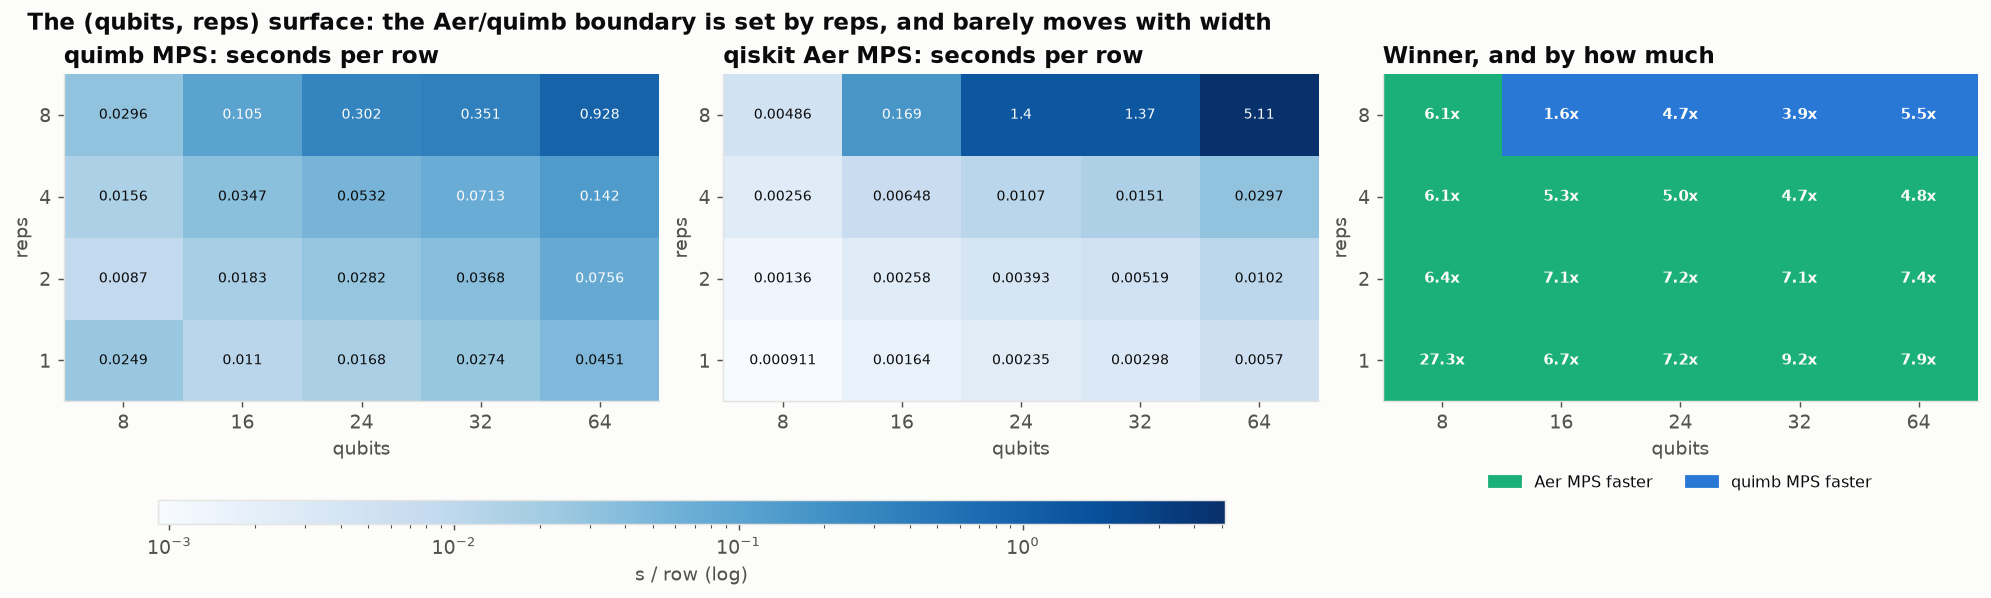

crossover reps per width (first reps where quimb beats Aer):
  n=8    -> > 8
  n=16   -> 8
  n=24   -> 8
  n=32   -> 8
  n=64   -> 8

n=24, where the dense statevector is still feasible:
backend  quimb MPS  qiskit Aer MPS  qiskit statevector
reps                                                  
1           0.0168          0.0023             10.6712
2           0.0282          0.0039             20.9915
4           0.0532          0.0107             41.9708
8           0.3019          1.4044             83.2040


In [11]:
def grid_of(df, backend, value="seconds"):
    g = np.full((len(SURF_REPS), len(SURF_N)), np.nan)
    for i, r in enumerate(SURF_REPS):
        for j, n in enumerate(SURF_N):
            sel = df[(df.backend == backend) & (df.n_qubits == n) & (df.reps == r)]
            if not sel.empty and sel[value].notna().all():
                g[i, j] = sel[value].iloc[0]
    return g

G_q, G_a = grid_of(df_surf_all, "quimb MPS"), grid_of(df_surf_all, "qiskit Aer MPS")

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.5), constrained_layout=True)

# Two magnitude heatmaps share ONE colour scale, so cells are comparable across panels.
vmin = np.nanmin([G_q, G_a]); vmax = np.nanmax([G_q, G_a])
for ax, G, name in zip(axes[:2], (G_q, G_a), ("quimb MPS", "qiskit Aer MPS")):
    im = ax.imshow(G, cmap=SEQ_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax),
                   origin="lower", aspect="auto")
    ax.set_title(f"{name}: seconds per row", loc="left")
    for i in range(len(SURF_REPS)):
        for j in range(len(SURF_N)):
            if not np.isnan(G[i, j]):
                # Ink colour flips on dark cells so the label stays legible.
                dark = G[i, j] > np.sqrt(vmin * vmax)
                ax.text(j, i, f"{G[i,j]:.3g}", ha="center", va="center", fontsize=8,
                        color=SURFACE if dark else INK)
    ax.set_xticks(range(len(SURF_N))); ax.set_xticklabels(SURF_N)
    ax.set_yticks(range(len(SURF_REPS))); ax.set_yticklabels(SURF_REPS)
    ax.set_xlabel("qubits"); ax.set_ylabel("reps"); ax.grid(False)
fig.colorbar(im, ax=axes[:2], label="s / row (log)", shrink=0.85,
             location="bottom", aspect=45, pad=0.02)

# Third panel: which engine wins. Two categories -> the two entity colours, not a ramp.
ax = axes[2]
winner = np.where(G_a < G_q, 0, 1)
from matplotlib.colors import ListedColormap
ax.imshow(winner, cmap=ListedColormap([SERIES_COLOR["qiskit Aer MPS"],
                                       SERIES_COLOR["quimb MPS"]]),
          origin="lower", aspect="auto", vmin=0, vmax=1)
for i in range(len(SURF_REPS)):
    for j in range(len(SURF_N)):
        ratio = max(G_q[i, j], G_a[i, j]) / min(G_q[i, j], G_a[i, j])
        ax.text(j, i, f"{ratio:.1f}x", ha="center", va="center", fontsize=8.5,
                color=SURFACE, fontweight="600")
ax.set_xticks(range(len(SURF_N))); ax.set_xticklabels(SURF_N)
ax.set_yticks(range(len(SURF_REPS))); ax.set_yticklabels(SURF_REPS)
ax.set_xlabel("qubits"); ax.set_ylabel("reps"); ax.grid(False)
ax.set_title("Winner, and by how much", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=SERIES_COLOR[b]) for b in
           ("qiskit Aer MPS", "quimb MPS")]
ax.legend(handles, ("Aer MPS faster", "quimb MPS faster"), loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

# No explicit y: constrained_layout only reserves room for the suptitle when it is
# allowed to place it, otherwise it lands on top of the panel titles.
fig.suptitle("The (qubits, reps) surface: the Aer/quimb boundary is set by reps, and "
             "barely moves with width",
             x=0.01, ha="left", fontsize=12.5, fontweight="600", color=INK)
plt.show()

print("crossover reps per width (first reps where quimb beats Aer):")
for j, n in enumerate(SURF_N):
    c = next((r for i, r in enumerate(SURF_REPS) if G_q[i, j] < G_a[i, j]), None)
    print(f"  n={n:<4} -> {c if c else '> ' + str(SURF_REPS[-1])}")
print("\nn=24, where the dense statevector is still feasible:")
sub = df_surf_all[(df_surf_all.n_qubits == 24)].pivot_table(
    index="reps", columns="backend", values="seconds", sort=False)
print(sub.round(4).to_string())

## 6. `full` entanglement, three-way — does exact contraction rescue it?

§4 showed both MPS engines lose to the dense statevector on `full` at `n=20`. That is not
the end of the story: the statevector is exponential, so it must eventually lose to
*something*. `quimb.tensor.Circuit` contracts the full tensor network exactly, with a
cotengra-optimised path and no truncation — a third option that is neither MPS nor dense.

This is the experiment that decides whether quimb has anything to offer for `full` at all.

In [12]:
FULL_N = [12, 16, 20, 24]
# n=24 'full' costs ~100 s/row on the statevector, so one row there.
df_full = sweep(["qiskit statevector", "quimb MPS", "quimb exact"],
                [(n, 1, "full", 2 if n < 24 else 1) for n in FULL_N])

  n=12   reps=1   full      qiskit statevector  0.0071s


  n=12   reps=1   full      quimb MPS           0.1628s


  n=12   reps=1   full      quimb exact         1.5503s


  n=16   reps=1   full      qiskit statevector  0.0734s


  n=16   reps=1   full      quimb MPS           1.3611s


...

  n=20   reps=1   full      quimb MPS           10.8171s


  n=20   reps=1   full      quimb exact         9.0645s


  n=24   reps=1   full      qiskit statevector  78.7577s


  n=24   reps=1   full      quimb MPS           68.7540s


  n=24   reps=1   full      quimb exact         16.5718s


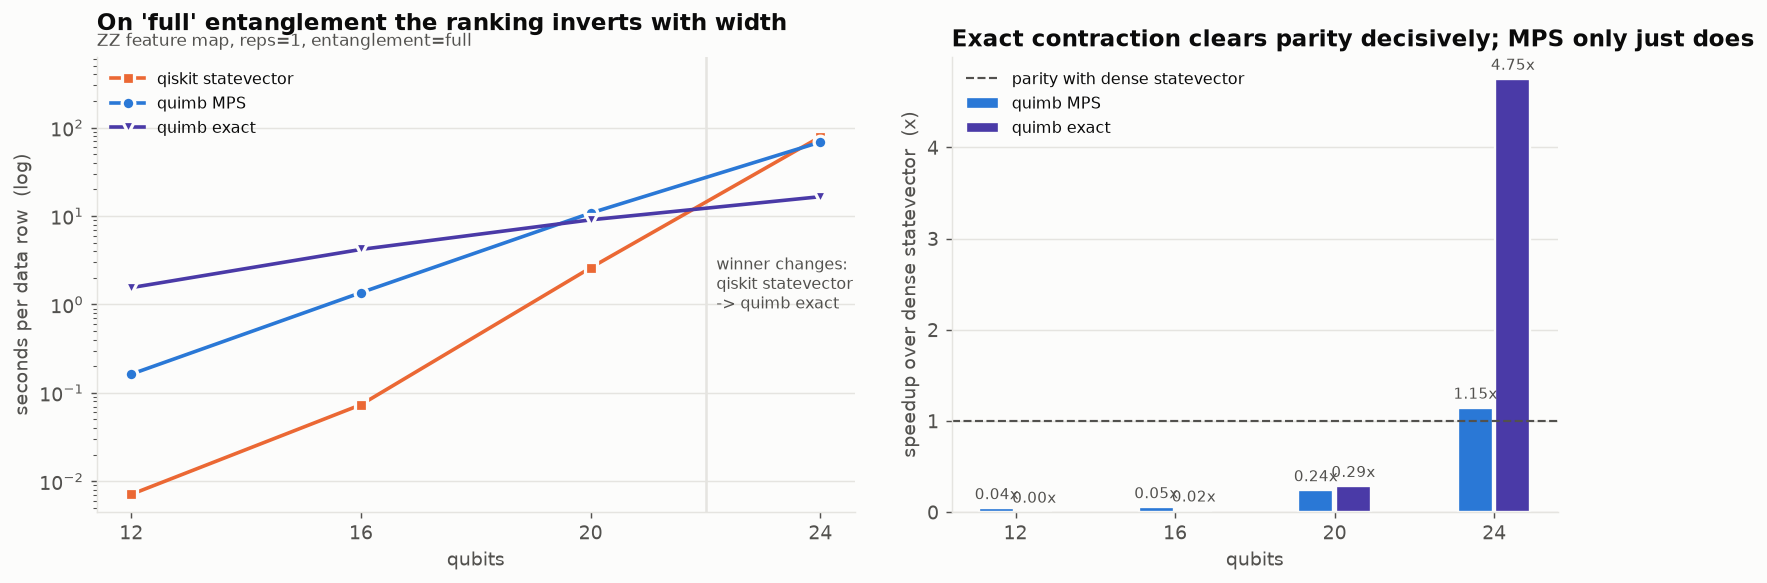

backend   qiskit statevector  quimb MPS  quimb exact
n_qubits                                            
12                     0.007      0.163        1.550
16                     0.073      1.361        4.194
20                     2.602     10.817        9.065
24                    78.758     68.754       16.572

fastest per width:
  n=12   qiskit statevector  (0.007 s/row)
  n=16   qiskit statevector  (0.073 s/row)
  n=20   qiskit statevector  (2.602 s/row)
  n=24   quimb exact         (16.572 s/row)


In [13]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.6),
                              gridspec_kw={"width_ratios": [1.25, 1]})
line_series(ax, df_full, "n_qubits",
            backends=["qiskit statevector", "quimb MPS", "quimb exact"])
time_axis(ax, "qubits", "On 'full' entanglement the ranking inverts with width",
          "ZZ feature map, reps=1, entanglement=full", legend="upper left")
ax.set_xticks(FULL_N); ax.set_xticklabels(map(str, FULL_N)); headroom(ax, 5)


def f(b, n):
    s = df_full[(df_full.backend == b) & (df_full.n_qubits == n)].seconds
    return s.iloc[0] if not s.empty and s.notna().all() else np.nan


# Mark where the winner changes, read from the data.
prev = None
for n in FULL_N:
    row = {b: f(b, n) for b in ("qiskit statevector", "quimb MPS", "quimb exact")}
    best = min(row, key=lambda k: row[k])
    if prev is not None and best != prev:
        ax.axvline(n - 2, color=GRID, linewidth=1.4, zorder=0)
        ax.annotate(f"winner changes:\n{prev}\n-> {best}", xy=(n - 2, 0.5),
                    xycoords=("data", "axes fraction"), xytext=(6, 0),
                    textcoords="offset points", fontsize=9, color=INK_2, va="center")
    prev = best

# Right: the ratio that matters -- how much better than the dense statevector.
xs = np.arange(len(FULL_N), dtype=float)
W = 0.22
for i, b in enumerate(("quimb MPS", "quimb exact")):
    vals = [f("qiskit statevector", n) / f(b, n) for n in FULL_N]
    pos = xs + (i - 0.5) * (W + 0.015)
    ax2.bar(pos, vals, W, label=b, color=SERIES_COLOR[b], edgecolor=SURFACE, linewidth=1.3)
    for xi, v in zip(pos, vals):
        ax2.annotate(f"{v:.2f}x", (xi, v), ha="center", va="bottom",
                     textcoords="offset points", xytext=(0, 3), fontsize=8.5, color=INK_2)
ax2.axhline(1.0, color=INK_2, linewidth=1.2, linestyle="--",
            label="parity with dense statevector")
ax2.set_xticks(xs); ax2.set_xticklabels(FULL_N)
ax2.set_xlabel("qubits"); ax2.set_ylabel("speedup over dense statevector  (x)")
ax2.set_title("Exact contraction clears parity decisively; MPS only just does",
              loc="left")
ax2.grid(axis="x", visible=False); ax2.legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

print(df_full.pivot_table(index="n_qubits", columns="backend", values="seconds",
                          sort=False).round(3).to_string())
print("\nfastest per width:")
for n in FULL_N:
    row = {b: f(b, n) for b in ("qiskit statevector", "quimb MPS", "quimb exact")}
    best = min(row, key=lambda k: row[k])
    print(f"  n={n:<4} {best:<19} ({row[best]:.3f} s/row)")

## 7. `max_bond` sweep on `full` — how much truncation survives?

Capping `max_bond` is the only way to make an MPS cheap on a state it cannot compress.
The question is whether the resulting features are still usable. `fidelity_estimate()` is
the **only** signal — nothing raises, and a truncated projection looks like a normal
array of numbers.

`n=20`, `reps=1`, `entanglement="full"` (uncapped bond 156).

In [14]:
MAX_BONDS = [2, 4, 8, 16, 32, 64, 128, None]
rows = []
for mb in MAX_BONDS:
    r = measure("quimb MPS", 20, 1, "full", nrows=2, max_bond=mb)
    rows.append({"max_bond": mb, **r})
    print(f"  max_bond={str(mb):<5} {r['seconds']:.3f}s  bond={r['bond']}  "
          f"fidelity={r['fidelity']:.6f}", flush=True)
df_mb = pd.DataFrame(rows)
sv_full = df_ent[(df_ent.backend == "qiskit statevector")
                 & (df_ent.entanglement == "full")].seconds.iloc[0]

  max_bond=2     0.412s  bond=2  fidelity=0.000000


  max_bond=4     0.438s  bond=4  fidelity=0.000009


  max_bond=8     0.544s  bond=8  fidelity=0.000023


  max_bond=16    0.851s  bond=16  fidelity=0.000424


  max_bond=32    2.175s  bond=32  fidelity=0.004607


  max_bond=64    4.603s  bond=64  fidelity=0.183680


  max_bond=128   10.938s  bond=128  fidelity=0.675518


  max_bond=None  10.817s  bond=156  fidelity=1.000000


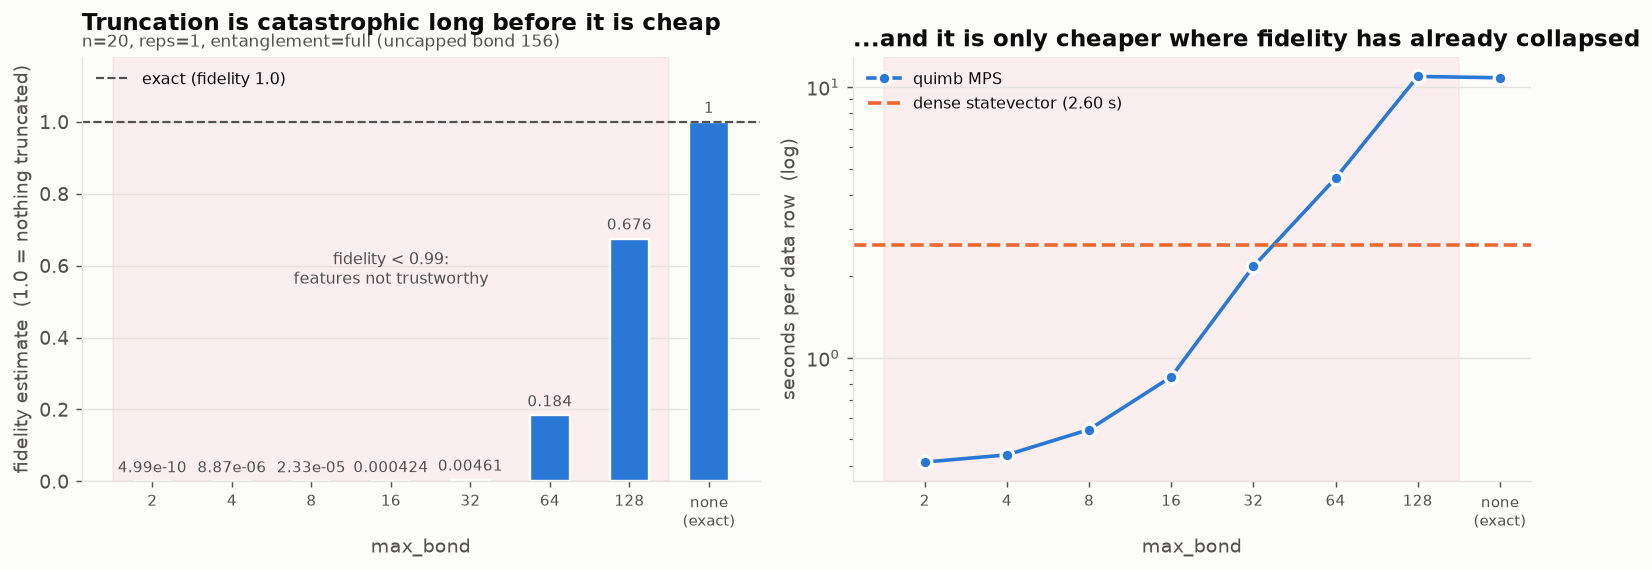


No capped max_bond reaches fidelity >= 0.99 -- only the uncapped run does.
There is no usable accuracy/speed operating point for 'full' at this width:
  caps cheaper than the dense statevector: [2, 4, 8, 16, 32] -- best fidelity among them 0.0046
uncapped cost 10.82 s vs dense statevector 2.60 s


In [15]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.5))
xs = np.arange(len(MAX_BONDS), dtype=float)
labels = [str(m) if m is not None else "none\n(exact)" for m in MAX_BONDS]

# Fidelity: the accuracy axis. Linear 0-1, zero baseline, because it is a fraction.
ax.bar(xs, df_mb.fidelity, 0.5, color=SERIES_COLOR["quimb MPS"],
       edgecolor=SURFACE, linewidth=1.3)
for xi, v in zip(xs, df_mb.fidelity):
    ax.annotate(f"{v:.3g}", (xi, v), ha="center", va="bottom", textcoords="offset points",
                xytext=(0, 3), fontsize=8.5, color=INK_2)
ax.axhline(1.0, color=INK_2, linewidth=1.2, linestyle="--", label="exact (fidelity 1.0)")
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(0, 1.18); ax.set_xlabel("max_bond")
ax.set_ylabel("fidelity estimate  (1.0 = nothing truncated)")
ax.set_title("Truncation is catastrophic long before it is cheap", loc="left", pad=15)
ax.text(0, 1.025, "n=20, reps=1, entanglement=full (uncapped bond 156)",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", fontsize=9)

# Time: the cost axis, log, with the statevector as the bar to beat.
ax2.plot(xs, df_mb.seconds, color=SERIES_COLOR["quimb MPS"], marker="o", markersize=7,
         linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8, label="quimb MPS")
ax2.axhline(sv_full, color=SERIES_COLOR["qiskit statevector"], linewidth=2,
            linestyle="--", label=f"dense statevector ({sv_full:.2f} s)")
ax2.set_yscale("log"); ax2.set_xticks(xs); ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_xlabel("max_bond"); ax2.set_ylabel("seconds per data row  (log)")
ax2.set_title("...and it is only cheaper where fidelity has already collapsed",
              loc="left")
ax2.grid(axis="x", visible=False); ax2.legend(loc="upper left", fontsize=9)

# Shade the region where features cannot be trusted.
bad = [i for i, v in enumerate(df_mb.fidelity) if v < 0.99]
if bad:
    for a in (ax, ax2):
        a.axvspan(-0.5, max(bad) + 0.5, color="#e34948", alpha=0.07, zorder=0)
    ax.annotate("fidelity < 0.99:\nfeatures not trustworthy",
                xy=(max(bad) / 2, 0.55), fontsize=9, color=INK_2, ha="center")
fig.tight_layout(); plt.show()

capped_ok = df_mb[(df_mb.fidelity >= 0.99) & df_mb.max_bond.notna()]
if capped_ok.empty:
    print("\nNo capped max_bond reaches fidelity >= 0.99 -- only the uncapped run does.")
    print("There is no usable accuracy/speed operating point for 'full' at this width:")
    cheap = df_mb[(df_mb.seconds < sv_full) & df_mb.max_bond.notna()]
    print(f"  caps cheaper than the dense statevector: "
          f"{sorted(int(m) for m in cheap.max_bond)} -- best fidelity among them "
          f"{cheap.fidelity.max():.2g}")
else:
    print(f"\nsmallest capped max_bond at fidelity >= 0.99: {int(capped_ok.max_bond.iloc[0])}")
print(f"uncapped cost {df_mb.seconds.iloc[-1]:.2f} s vs dense statevector {sv_full:.2f} s")

## 8. `CircuitPermMPS` — does lazy permutation help non-local patterns?

`CircuitMPS` applies a non-local gate by swapping the two qubits together and then
**swapping them back**. `CircuitPermMPS` skips the swap-back and tracks the permutation
instead, which should pay exactly where locality is violated: `circular` (one wrap-around
gate), `sca`, and `full` (every pair).

Both simulators are read with the **same** batched RDM sweep here. An earlier draft gave the sweep only to `CircuitMPS` and let `CircuitPermMPS` fall back to the slower per-expectation path, which made lazy permutation look ~20% *slower* on `linear` — that was a comparison of read strategies, not of simulators.

In [16]:
PERM_PATTERNS = ["linear", "circular", "sca", "full"]
df_perm = sweep(["quimb MPS", "quimb PermMPS"],
                [(20, 1, e) if e != "full" else (20, 1, e, 2) for e in PERM_PATTERNS])

  n=20   reps=1   linear    quimb MPS           0.0130s


  n=20   reps=1   linear    quimb PermMPS       0.0148s


  n=20   reps=1   circular  quimb MPS           0.0175s


  n=20   reps=1   circular  quimb PermMPS       0.0197s


  n=20   reps=1   sca       quimb MPS           0.0189s


  n=20   reps=1   sca       quimb PermMPS       0.0205s


  n=20   reps=1   full      quimb MPS           10.8171s


  n=20   reps=1   full      quimb PermMPS       7.7153s


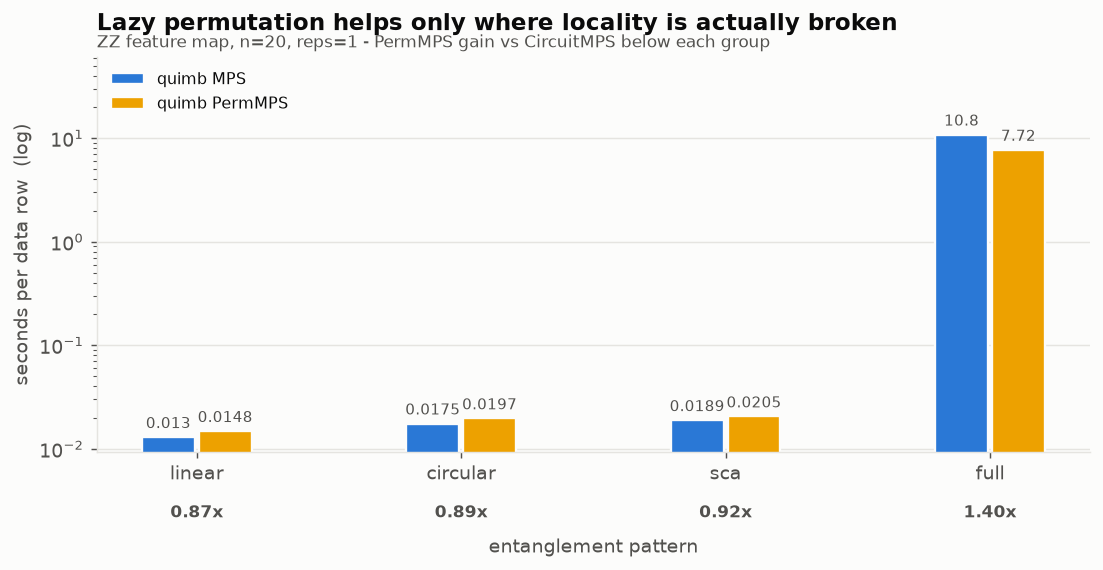

linear     MPS   0.0130s   PermMPS   0.0148s   gain 0.87x
circular   MPS   0.0175s   PermMPS   0.0197s   gain 0.89x
sca        MPS   0.0189s   PermMPS   0.0205s   gain 0.92x
full       MPS  10.8171s   PermMPS   7.7153s   gain 1.40x

Even at its best, PermMPS on 'full' (7.72 s) stays above the dense statevector (2.60 s) -- the verdict in section 4 stands.


In [17]:
fig, ax = plt.subplots(figsize=(8.6, 4.5))
xs = np.arange(len(PERM_PATTERNS), dtype=float)
W = 0.2


def pm(b, e):
    return df_perm[(df_perm.backend == b) & (df_perm.entanglement == e)].seconds.iloc[0]


for i, b in enumerate(("quimb MPS", "quimb PermMPS")):
    vals = [pm(b, e) for e in PERM_PATTERNS]
    pos = xs + (i - 0.5) * (W + 0.015)
    ax.bar(pos, vals, W, label=b, color=SERIES_COLOR[b], edgecolor=SURFACE, linewidth=1.3)
    for xi, v in zip(pos, vals):
        ax.annotate(f"{v:.3g}", (xi, v), ha="center", va="bottom",
                    textcoords="offset points", xytext=(0, 3), fontsize=8.5, color=INK_2)

for j, e in enumerate(PERM_PATTERNS):
    gain = pm("quimb MPS", e) / pm("quimb PermMPS", e)
    # y anchored in axes fraction: (xs[j], 0) in DATA coords is -inf on a log axis,
    # so this annotation silently never rendered in an earlier draft.
    ax.annotate(f"{gain:.2f}x", xy=(xs[j], 0), xycoords=("data", "axes fraction"),
                xytext=(0, -36), textcoords="offset points",
                ha="center", fontsize=9.5, color=INK_2, fontweight="600")

ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(PERM_PATTERNS)
ax.set_xlabel("entanglement pattern", labelpad=30)
ax.set_ylabel("seconds per data row  (log)")
ax.set_title("Lazy permutation helps only where locality is actually broken",
             loc="left", pad=15)
ax.text(0, 1.025, "ZZ feature map, n=20, reps=1 - PermMPS gain vs CircuitMPS below each group", transform=ax.transAxes,
        fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", fontsize=9)
headroom(ax, 4)
fig.tight_layout(); plt.show()

for e in PERM_PATTERNS:
    print(f"{e:<10} MPS {pm('quimb MPS', e):8.4f}s   PermMPS {pm('quimb PermMPS', e):8.4f}s"
          f"   gain {pm('quimb MPS', e)/pm('quimb PermMPS', e):.2f}x")
print(f"\nEven at its best, PermMPS on 'full' ({pm('quimb PermMPS','full'):.2f} s) stays "
      f"above the dense statevector ({sv_full:.2f} s) -- the verdict in section 4 stands.")

## 9. Batched expectation read

Every expectation value moves the MPS orthogonality centre. Asking for `<X>` on all
sites, then `<Y>`, then `<Z>` drags the centre across the chain three times and rebuilds
each site's environment three times.

`MPSFeatureMapProjector` instead sweeps sites once, forming each site's 2x2 reduced
density matrix and tracing it against X, Y and Z. This measures the three strategies
directly — the middle one isolates how much comes from ordering alone.

In [18]:
import quimb.tensor as qtn
from qbiocode.utils.mps_backend import qiskit_circuit_to_quimb_gates

PAULI_ARR = [np.asarray(quimb.pauli(p)) for p in "XYZ"]


def _gates(n, reps, ent):
    p = make_projector(n, reps=reps, entanglement=ent, backend="quimb_mps")
    x = np.linspace(0.1, 3.0, n)
    return qiskit_circuit_to_quimb_gates(p.circuit.assign_parameters(x)), n


def _pauli_major(c, n):        # 3 sweeps of the orthogonality centre
    return np.array([[c.local_expectation(quimb.pauli(p), k).real for k in range(n)]
                     for p in "XYZ"])


def _site_major(c, n):         # 1 sweep, but still 3n environment builds
    out = np.empty((3, n))
    for k in range(n):
        for j, p in enumerate("XYZ"):
            out[j, k] = c.local_expectation(quimb.pauli(p), k).real
    return out


def _rdm_sweep(c, n):          # 1 sweep, n environment builds, 3 cheap 2x2 traces each
    psi, info, out = c._psi, c.gate_opts["info"], np.empty((3, n))
    for k in range(n):
        rho = np.asarray(psi.partial_trace_to_dense_canonical(k, normalized=True, info=info))
        for j, P in enumerate(PAULI_ARR):
            out[j, k] = np.trace(P @ rho).real
    return out


STRATEGIES = {"Pauli-major (3 sweeps)": _pauli_major,
              "site-major (1 sweep)": _site_major,
              "RDM sweep (shipped)": _rdm_sweep}
READ_CASES = [(20, 1, "linear"), (64, 1, "linear"), (128, 1, "linear"),
              (256, 1, "linear"), (20, 8, "pairwise")]

read_rows = []
for n, reps, ent in READ_CASES:
    g, _ = _gates(n, reps, ent)
    ref = None
    for name, fn in STRATEGIES.items():
        c = qtn.CircuitMPS(N=n, cutoff=1e-12); c.apply_gates(g); fn(c, n)      # warm
        c = qtn.CircuitMPS(N=n, cutoff=1e-12); c.apply_gates(g)
        t = time.perf_counter(); r = fn(c, n); dt = time.perf_counter() - t
        ref = r if ref is None else ref
        read_rows.append({"case": f"n={n}, reps={reps}\n{ent}", "strategy": name,
                          "seconds": dt, "maxdiff": float(np.abs(r - ref).max())})
df_read = pd.DataFrame(read_rows)
print(f"max disagreement between strategies: {df_read.maxdiff.max():.1e}  (all equivalent)")

max disagreement between strategies: 4.7e-11  (all equivalent)


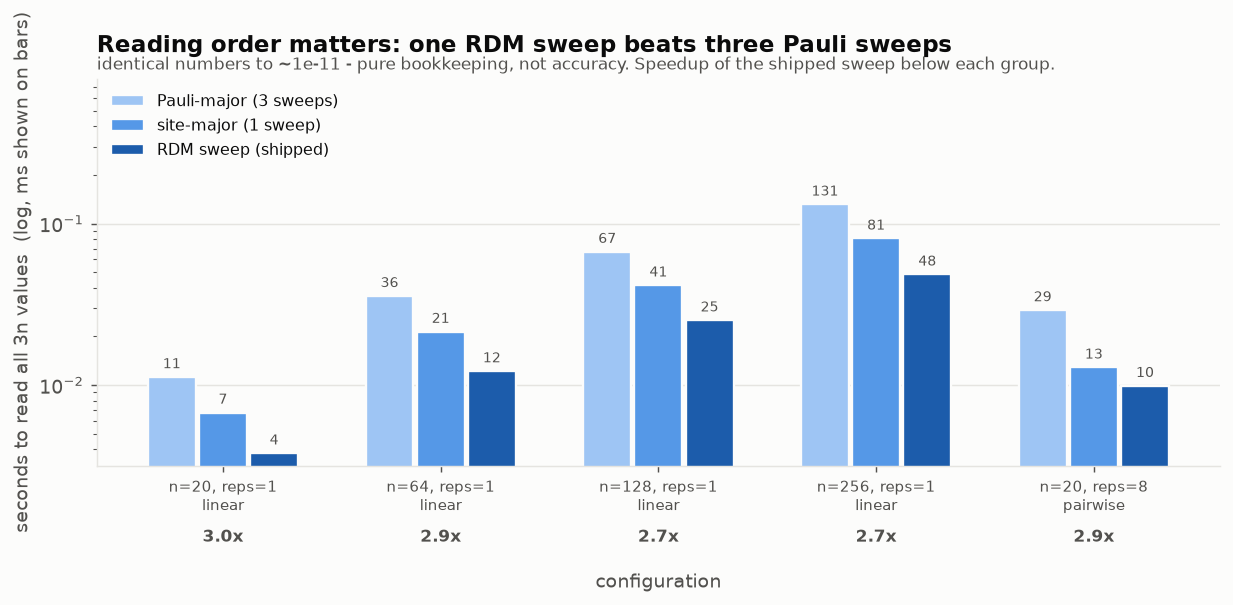

strategy                Pauli-major (3 sweeps)  site-major (1 sweep)  RDM sweep (shipped)
case                                                                                     
n=20, reps=1\nlinear                    0.0112                0.0067               0.0038
n=64, reps=1\nlinear                    0.0356                0.0214               0.0122
n=128, reps=1\nlinear                   0.0669                0.0414               0.0252
n=256, reps=1\nlinear                   0.1314                0.0808               0.0484
n=20, reps=8\npairwise                  0.0291                0.0128               0.0099


In [19]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
cases = df_read.case.unique()
xs = np.arange(len(cases), dtype=float)
W = 0.22
# Ordered strategies (worst -> best), so an ordinal ramp of one hue is the right encoding.
RAMP = ["#9ec5f4", "#5598e7", "#1c5cab"]

for i, (name, colour) in enumerate(zip(STRATEGIES, RAMP)):
    vals = [df_read[(df_read.case == c) & (df_read.strategy == name)].seconds.iloc[0]
            for c in cases]
    pos = xs + (i - 1) * (W + 0.015)
    ax.bar(pos, vals, W, label=name, color=colour, edgecolor=SURFACE, linewidth=1.3)
    for xi, v in zip(pos, vals):
        ax.annotate(f"{v*1000:.0f}", (xi, v), ha="center", va="bottom",
                    textcoords="offset points", xytext=(0, 3), fontsize=8, color=INK_2)

for j, c in enumerate(cases):
    slow = df_read[(df_read.case == c) & (df_read.strategy == "Pauli-major (3 sweeps)")].seconds.iloc[0]
    fast = df_read[(df_read.case == c) & (df_read.strategy == "RDM sweep (shipped)")].seconds.iloc[0]
    ax.annotate(f"{slow/fast:.1f}x", xy=(xs[j], 0), xycoords=("data", "axes fraction"),
                xytext=(0, -42), textcoords="offset points", ha="center",
                fontsize=9.5, color=INK_2, fontweight="600")

ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(cases, fontsize=8.5)
ax.set_xlabel("configuration", labelpad=32)
ax.set_ylabel("seconds to read all 3n values  (log, ms shown on bars)")
ax.set_title("Reading order matters: one RDM sweep beats three Pauli sweeps",
             loc="left", pad=15)
ax.text(0, 1.025, "identical numbers to ~1e-11 - pure bookkeeping, not accuracy. Speedup of the shipped sweep below each group.",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", fontsize=9); headroom(ax, 5)
fig.tight_layout(); plt.show()

print(df_read.pivot_table(index="case", columns="strategy", values="seconds",
                          sort=False).round(4).to_string())

## 10. Row-level parallelism with joblib

Data rows are independent, so `project(X, n_jobs=-1)` splits them across processes.
Processes, not threads: the per-row work is numpy/numba in one interpreter, and
`OMP_NUM_THREADS=1` is mandatory here anyway.

The catch is a **one-time per-process cost** — the loky worker pool plus a numba JIT
warm-up in each worker. On a small dataset that cost dominates and parallelism makes
things *worse*. This finds the break-even.

In [20]:
PAR_ROWS = [24, 96, 384]
proj_par = make_projector(64, reps=1, entanglement="linear", backend="quimb_mps")
par_rows = []
for rows in PAR_ROWS:
    X = np.random.default_rng(0).uniform(0, np.pi, (rows, 64))
    proj_par.project_row(X[0])
    t = time.perf_counter(); a = proj_par.project(X, progress_every=None, n_jobs=1)
    t_seq = time.perf_counter() - t
    t = time.perf_counter(); b = proj_par.project(X, progress_every=None, n_jobs=-1)
    t_par = time.perf_counter() - t
    par_rows.append({"rows": rows, "sequential": t_seq, "parallel": t_par,
                     "speedup": t_seq / t_par, "maxdiff": float(np.abs(a - b).max())})
    print(f"  rows={rows:<5} seq {t_seq:6.2f}s  par {t_par:6.2f}s  "
          f"speedup {t_seq/t_par:5.1f}x  maxdiff {np.abs(a-b).max():.0e}", flush=True)
df_par = pd.DataFrame(par_rows)
assert df_par.maxdiff.max() == 0, "parallel and sequential results must be identical"

  rows=24    seq   0.95s  par   9.18s  speedup   0.1x  maxdiff 0e+00


  rows=96    seq   3.85s  par   0.47s  speedup   8.2x  maxdiff 0e+00


  rows=384   seq  14.53s  par   1.70s  speedup   8.6x  maxdiff 0e+00


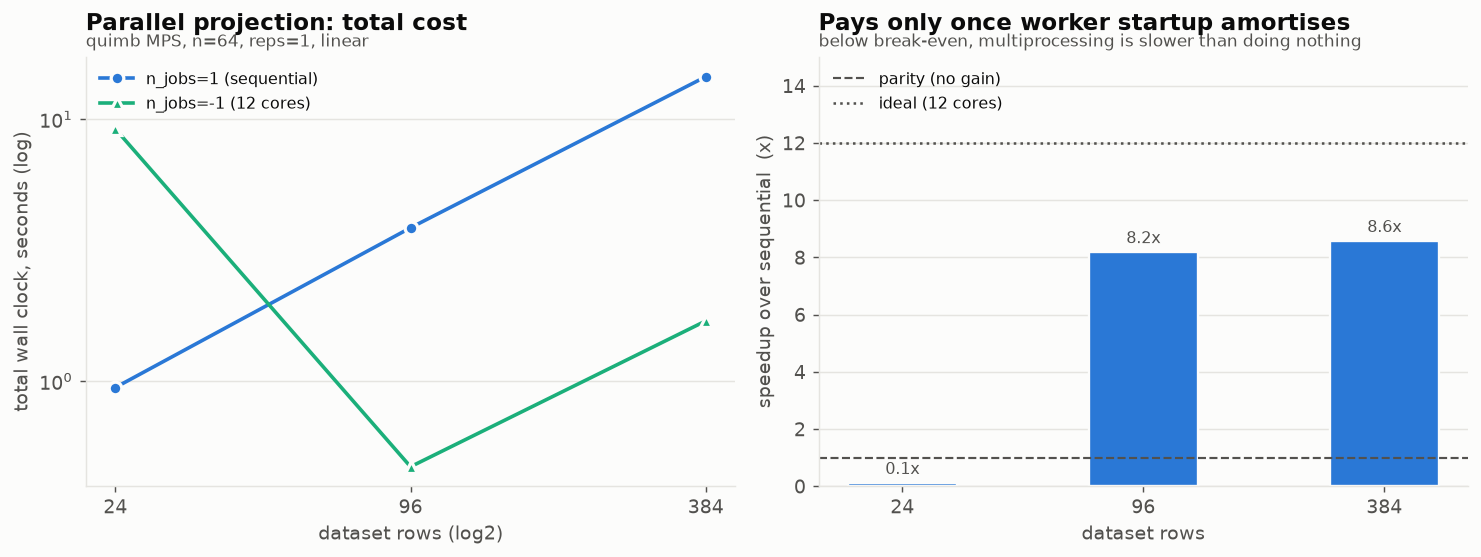

 rows  sequential  parallel  speedup  maxdiff
   24        0.95      9.18     0.10      0.0
   96        3.85      0.47     8.17      0.0
  384       14.53      1.70     8.56      0.0


In [21]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.4))

ax.plot(df_par.rows, df_par.sequential, color=SERIES_COLOR["quimb MPS"], marker="o",
        markersize=7, linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8,
        label="n_jobs=1 (sequential)")
ax.plot(df_par.rows, df_par.parallel, color=SERIES_COLOR["qiskit Aer MPS"], marker="^",
        markersize=7, linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8,
        label=f"n_jobs=-1 ({os.cpu_count()} cores)")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(PAR_ROWS); ax.set_xticklabels(map(str, PAR_ROWS)); ax.minorticks_off()
ax.set_xlabel("dataset rows (log2)"); ax.set_ylabel("total wall clock, seconds (log)")
ax.set_title("Parallel projection: total cost", loc="left", pad=15)
ax.text(0, 1.025, "quimb MPS, n=64, reps=1, linear", transform=ax.transAxes,
        fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", fontsize=9)

# Speedup on a linear zero-baseline axis: 1.0 is parity, the core count is the ceiling.
ax2.bar(np.arange(len(df_par)), df_par.speedup, 0.45,
        color=SERIES_COLOR["quimb MPS"], edgecolor=SURFACE, linewidth=1.3)
for i, v in enumerate(df_par.speedup):
    ax2.annotate(f"{v:.1f}x", (i, v), ha="center", va="bottom",
                 textcoords="offset points", xytext=(0, 3), fontsize=9, color=INK_2)
ax2.axhline(1.0, color=INK_2, linewidth=1.2, linestyle="--", label="parity (no gain)")
ax2.axhline(os.cpu_count(), color=INK_2, linewidth=1.4, linestyle=":",
            label=f"ideal ({os.cpu_count()} cores)")
ax2.set_xticks(range(len(df_par))); ax2.set_xticklabels(df_par.rows)
ax2.set_xlabel("dataset rows"); ax2.set_ylabel("speedup over sequential  (x)")
ax2.set_title("Pays only once worker startup amortises", loc="left", pad=15)
ax2.text(0, 1.025, "below break-even, multiprocessing is slower than doing nothing",
         transform=ax2.transAxes, fontsize=9.5, color=INK_2)
ax2.set_ylim(0, os.cpu_count() * 1.25); ax2.grid(axis="x", visible=False)
ax2.legend(loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

print(df_par.round(2).to_string(index=False))

## 11. The overhead the pipelines pay today

`compute_qpl` and `compute_pqk` call `StatevectorEstimator`, which **re-simulates the
circuit once per observable**. With 3n observables that is a ~3n-fold overhead unrelated
to simulation method — and it is the cheapest fix available, independent of everything
else in this notebook.

In [22]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector

n = 20
# The same parameterised feature map both paths below evaluate.
fm = make_projector(n, reps=1, entanglement="linear", backend="statevector").circuit
obs = [SparsePauliOp.from_sparse_list([(p, [k], 1.0)], num_qubits=n)
       for p in "XYZ" for k in range(n)]
x = np.random.default_rng(0).uniform(0, np.pi, n)

# Cost is exactly linear in the number of observables -> it re-simulates each time.
per_obs = []
for k in (1, 5, 10, 20):
    t = time.perf_counter(); StatevectorEstimator(seed=1).run([(fm, obs[:k], x)]).result()
    per_obs.append((k, time.perf_counter() - t))
    print(f"  {k:>3} observable(s): {per_obs[-1][1]:6.3f}s  "
          f"({per_obs[-1][1]/k:.3f}s each)")

t = time.perf_counter(); StatevectorEstimator(seed=1).run([(fm, obs, x)]).result()
t_est = time.perf_counter() - t
t = time.perf_counter()
sv = Statevector(fm.assign_parameters(x)); [sv.expectation_value(o).real for o in obs]
t_direct = time.perf_counter() - t
best_backend = df_ent[(df_ent.entanglement == "linear")].sort_values("seconds").iloc[0]

print(f"\nStatevectorEstimator (pipeline today) : {t_est:8.3f} s/row")
print(f"Statevector directly (same numbers)   : {t_direct:8.3f} s/row"
      f"   -> {t_est/t_direct:.0f}x overhead, no accuracy change")
print(f"{best_backend.backend} (best measured)      : {best_backend.seconds:8.4f} s/row"
      f"   -> {t_est/best_backend.seconds:.0f}x faster than today")

    1 observable(s):  0.448s  (0.448s each)


    5 observable(s):  2.136s  (0.427s each)


   10 observable(s):  4.252s  (0.425s each)


   20 observable(s):  8.562s  (0.428s each)



StatevectorEstimator (pipeline today) :   25.567 s/row
Statevector directly (same numbers)   :    0.443 s/row   -> 58x overhead, no accuracy change
qiskit Aer MPS (best measured)      :   0.0020 s/row   -> 12659x faster than today


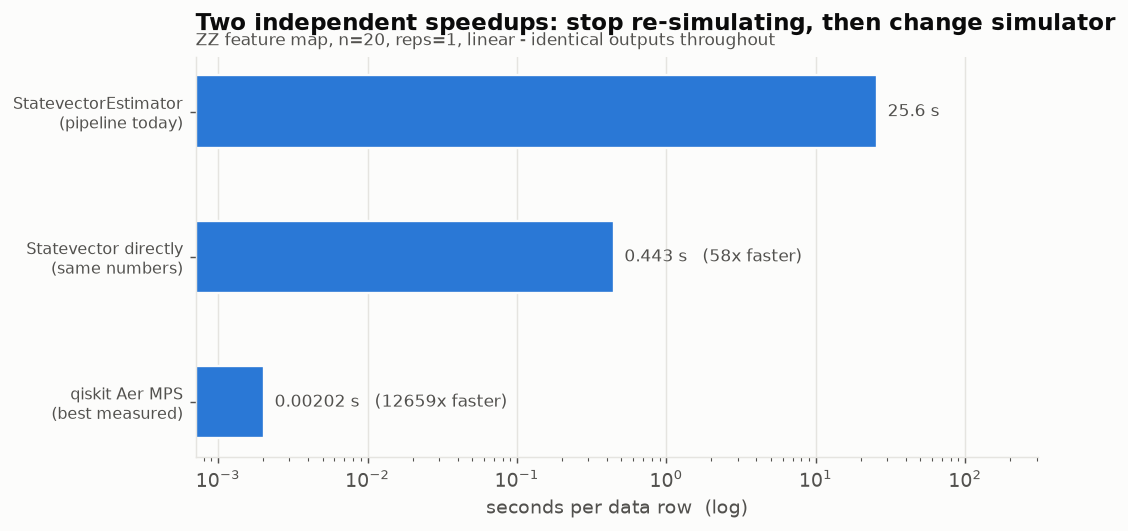

In [23]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
stages = ["StatevectorEstimator\n(pipeline today)", "Statevector directly\n(same numbers)",
          f"{best_backend.backend}\n(best measured)"]
vals = [t_est, t_direct, best_backend.seconds]
# One series -> one colour; the ordinal ramp would double-encode length as hue.
bars = ax.barh(range(3)[::-1], vals, 0.5, color=SERIES_COLOR["quimb MPS"],
               edgecolor=SURFACE, linewidth=1.3)
for i, v in zip(range(3)[::-1], vals):
    ax.annotate(f"{v:.3g} s   ({t_est/v:.0f}x faster)" if v != t_est else f"{v:.3g} s",
                (v, i), xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, color=INK_2)
ax.set_xscale("log"); ax.set_yticks(range(3)[::-1]); ax.set_yticklabels(stages, fontsize=9)
ax.set_xlabel("seconds per data row  (log)")
ax.set_xlim(min(vals) * 0.35, max(vals) * 12)
ax.set_title("Two independent speedups: stop re-simulating, then change simulator",
             loc="left", pad=15)
ax.text(0, 1.03, "ZZ feature map, n=20, reps=1, linear - identical outputs throughout",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

## 12. Conclusions

### The dispatch rule, as measured

`qbiocode.utils.projection.choose_backend` encodes exactly this:

```python
MPS_FRIENDLY = {"linear", "reverse_linear", "pairwise", "circular", "sca"}

if entanglement not in MPS_FRIENDLY:          # 'full'
    backend = "quimb_exact" if n_qubits >= 24 else "statevector"
elif reps <= 6:
    backend = "aer_mps"                        # ~10x quimb, ~200x dense
else:
    backend = "quimb_mps"                      # degrades far more gracefully with depth
```

### What each section establishes

1. **Width is no longer the constraint** (§2). Both MPS engines are linear in `n` on
   bounded patterns; 256 qubits costs less than the dense statevector at 20, which is
   RAM-bound near 30.
2. **Depth is the constraint, and it separates the engines** (§3, §5). The Aer/quimb
   crossover sits between `reps=6` and `reps=8` and barely moves with width — so the rule
   can key on `reps` alone.
3. **`entanglement` picks the simulator** (§4). Bounded patterns favour an MPS by 17-210x;
   `full` reverses it at `n=20`.
4. **But `full` is not a dead end** (§6). The dense statevector is exponential, so it loses
   eventually: by `n=24` quimb's exact contraction is the fastest of all three. `full`
   should route to `quimb_exact` at large width, not to an MPS.
5. **Truncation is not a usable dial here** (§7). On `full`, fidelity collapses long before
   the cost approaches the statevector's, so there is no useful operating point. Any capped
   run must report `fidelity_estimate()` alongside its accuracy numbers.
6. **`CircuitPermMPS` is a constant factor, not a regime change** (§8).
7. **Reading order was worth 1.6-3.3x for free** (§9) — pure bookkeeping, identical numbers.
8. **Parallelism pays, but only above a break-even** (§10). Worker startup makes small
   datasets slower; from a few hundred rows it approaches the core count.
9. **The pipeline's biggest single win needs no new dependency** (§11).

### On GPUs

Not worth it here, for two independent reasons:

- **Impossible on this machine.** No CUDA; torch's Metal backend raises
  `geqrf: MPS currently supports float32 only`, and MPS gate application needs complex
  QR/SVD. Aer reports `devices: ('CPU',)`.
- **Wrong shape of work even with CUDA.** At bond dimension 2-102 the tensors are a few
  kB and the work is thousands of *sequentially dependent* tiny contractions, so
  kernel-launch overhead dominates. GPUs pay off at bond dimensions in the
  hundreds-to-thousands.

§10's row-level parallelism is the scaling lever that actually applies.

### Caveats

- Timings are per data row on one 12-core machine with `OMP_NUM_THREADS=1`. Treat the
  *boundaries* as the result; absolute numbers will move.
- `N_ROWS = 5`, with expensive cells down to 1-2 rows. Raise it before quoting any of
  these numbers as precise.
- Everything here is wall clock. Whether wider bounded-entanglement feature maps produce
  *better models* than narrow `full` ones is a separate experiment, and the one that
  decides whether any of this matters scientifically.